# **ENVIROMENT INITIALIZATION**

In [1]:
# IMPORTS
# Math libraries
import numpy as np
import pandas as pd
import polars as pl

# Plots
import matplotlib.pyplot as plt

# Technical libraries
from datetime import timedelta

# ML libraries
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

In [2]:
# CONFIGURATION
from config import (
    PROJECT_ROOT,
    CV_AS_OF, CV_TARGET_START, CV_TARGET_END,
    DATA_RAW_DIR, DATA_PROCESSED_DIR, DATA_FEATURES_DIR,
    TRAIN_PATH, CV_TARGET_PATH, HISTORY_PATH, CV_FEATURES_PATH, CV_SPLIT_PATH,
    REPORTS_DIR, REPORTS_GMV_DIR, REPORTS_CONV_FUNL_DIR, REPORTS_FEATURES_DIR,
    REPORTS_MODELS_DIR, REPORTS_MODELS_GRAPHS_DIR,
    BIN_ORDER, WINDOWS,
    RANDOM_STATE
)

In [3]:
# DATA LOADING
train_lf = pl.scan_parquet(TRAIN_PATH)
print(f"Train data loaded: {train_lf.collect_schema()}")

history_lf = pl.scan_parquet(HISTORY_PATH)

cv_target_lf = pl.scan_parquet(CV_TARGET_PATH)
cv_target = pl.read_parquet(CV_TARGET_PATH)

Train data loaded: Schema({'event_date': Date, 'user_id': Int64, 'search': Int64, 'cat': Int64, 'has_search_to_cart': Int64, 'has_search_to_ord': Int64, 'has_cat_to_cart': Int64, 'has_cat_to_ord': Int64, 'search_to_cart': Int64, 'search_to_ord': Int64, 'cat_to_cart': Int64, 'cat_to_ord': Int64, 'gmv_search': Float64, 'gmv_cat': Float64, 'to_cart': Int64, 'to_ord': Int64, 'gmv': Float64, 'searches': Int64})


# **FEATURE ENGINEERING**

| Категория | Фичи | Обоснование |
|---|---|---|
| **Recency** | days_since_last_activity, days_since_last_purchase, days_since_last_order, days_since_last_cart, days_since_last_search | Пользователи с недавней активностью конвертируют лучше |
| **Frequency** | active_days_last_7/14/30/60/90d, purchase_days_last_7/14/30/60/90d, orders_last_7/14/30/60/90d, searches_last_7/14/30/60/90d | Частота — главный драйвер различий (328 vs 7 заказов) |
| **Monetary** | gmv_last_7/14/30/60/90/180/365d, avg_order_value_last_30d, avg_order_value_last_90d | GMV за разные окна, средний чек |
| **Conversion** | cart_to_order_rate, search_to_cart_rate, search_to_order_rate, cat_to_cart_rate, cat_to_order_rate | Конверсии на разных этапах воронки |
| **Channel** | search_share, cat_share, uses_both_channels_hist, gmv_search_share | Доля каналов в активности |
| **Trend** | gmv_7d / gmv_30d, gmv_30d / gmv_90d, active_days_7d / active_days_30d | Ускорение/замедление активности |
| **Seasonal** | weekday, is_weekend, week_of_month, days_to_next_salary, days_since_last_salary, days_to_holiday, is_holiday_week | Зарплатные циклы, праздники, недельная сезонность |
| **Funnel** | avg_items_per_order, avg_cart_adds_per_day, avg_searches_per_day | Интенсивность на каждом этапе |
| **Historical** | gmv_same_period_last_year (если данные позволяют) | YoY baseline |

## **DESIGNING NEW FEATURES**

In [4]:
# FEATURE ENGINEERING: RECENCY FEATURES
# Days since last activity / purchase / order / cart

recency_features = (
    history_lf.group_by("user_id")
    .agg([
        # Recency: days since last activity of any type
        pl.col("event_date").max().alias("last_activity_date"),
        
        # Recency: days since last purchase
        pl.col("event_date").filter(pl.col("to_ord") > 0).max().alias("last_order_date"),
        
        # Recency: days since last cart addition
        pl.col("event_date").filter(pl.col("to_cart") > 0).max().alias("last_cart_date"),
        
        # Recency: days since last search
        pl.col("event_date").filter(pl.col("search") == 1).max().alias("last_search_date"),
        
        # Recency: days since last catalog use
        pl.col("event_date").filter(pl.col("cat") == 1).max().alias("last_cat_date"),
    ])
    .with_columns([
        # Calculate days since last activity
        (pl.lit(CV_AS_OF) - pl.col("last_activity_date")).dt.total_days().alias("recency_activity"),
        (pl.lit(CV_AS_OF) - pl.col("last_order_date")).dt.total_days().alias("recency_order"),
        (pl.lit(CV_AS_OF) - pl.col("last_cart_date")).dt.total_days().alias("recency_cart"),
        (pl.lit(CV_AS_OF) - pl.col("last_search_date")).dt.total_days().alias("recency_search"),
        (pl.lit(CV_AS_OF) - pl.col("last_cat_date")).dt.total_days().alias("recency_cat"),
    ])
    .drop([
        "last_activity_date",
        "last_order_date",
        "last_cart_date",
        "last_search_date",
        "last_cat_date"
    ])
    .collect()
)

# Fill missing values (if event did not occur)
recency_features = recency_features.fill_null(999)

print(f"Recency features shape: {recency_features.shape}")
print(recency_features.head())

Recency features shape: (250000, 6)
shape: (5, 6)
┌─────────┬──────────────────┬───────────────┬──────────────┬────────────────┬─────────────┐
│ user_id ┆ recency_activity ┆ recency_order ┆ recency_cart ┆ recency_search ┆ recency_cat │
│ ---     ┆ ---              ┆ ---           ┆ ---          ┆ ---            ┆ ---         │
│ i64     ┆ i64              ┆ i64           ┆ i64          ┆ i64            ┆ i64         │
╞═════════╪══════════════════╪═══════════════╪══════════════╪════════════════╪═════════════╡
│ 890307  ┆ 0                ┆ 50            ┆ 45           ┆ 0              ┆ 0           │
│ 190335  ┆ 2                ┆ 58            ┆ 42           ┆ 3              ┆ 93          │
│ 531824  ┆ 3                ┆ 6             ┆ 6            ┆ 6              ┆ 242         │
│ 884168  ┆ 0                ┆ 74            ┆ 16           ┆ 5              ┆ 0           │
│ 665778  ┆ 1                ┆ 10            ┆ 8            ┆ 1              ┆ 67          │
└─────────┴─────────

In [5]:
# FEATURE ENGINEERING: FREQUENCY FEATURES
# Number of events over different time windows

frequency_exprs = []

for w in WINDOWS:
    window_start = CV_AS_OF - timedelta(days = w)
    
    frequency_exprs.extend([
        # Number of active days in the window
        pl.col("event_date").filter(
            (pl.col("event_date") >= window_start) & 
            (pl.col("event_date") <= CV_AS_OF)
        ).n_unique().alias(f"active_days_{w}d"),
        
        # Number of orders in the window
        pl.col("to_ord").filter(
            (pl.col("event_date") >= window_start) & 
            (pl.col("event_date") <= CV_AS_OF)
        ).sum().alias(f"orders_{w}d"),
        
        # Number of cart additions in the window
        pl.col("to_cart").filter(
            (pl.col("event_date") >= window_start) & 
            (pl.col("event_date") <= CV_AS_OF)
        ).sum().alias(f"cart_adds_{w}d"),
        
        # Number of search queries in the window
        pl.col("searches").filter(
            (pl.col("event_date") >= window_start) & 
            (pl.col("event_date") <= CV_AS_OF)
        ).sum().alias(f"searches_{w}d"),
    ])

frequency_features = (
    history_lf.group_by("user_id")
    .agg(frequency_exprs)
    .collect()
)

print(f"Frequency features shape: {frequency_features.shape}")
print(frequency_features.head())

Frequency features shape: (250000, 17)
shape: (5, 17)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ user_id ┆ active_day ┆ orders_7d ┆ cart_adds ┆ … ┆ active_da ┆ orders_90 ┆ cart_adds ┆ searches_ │
│ ---     ┆ s_7d       ┆ ---       ┆ _7d       ┆   ┆ ys_90d    ┆ d         ┆ _90d      ┆ 90d       │
│ i64     ┆ ---        ┆ i64       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│         ┆ u32        ┆           ┆ i64       ┆   ┆ u32       ┆ i64       ┆ i64       ┆ i64       │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 501661  ┆ 2          ┆ 1         ┆ 2         ┆ … ┆ 33        ┆ 11        ┆ 17        ┆ 42        │
│ 825679  ┆ 2          ┆ 0         ┆ 0         ┆ … ┆ 33        ┆ 0         ┆ 36        ┆ 87        │
│ 861603  ┆ 7          ┆ 1         ┆ 3         ┆ … ┆ 50        ┆ 5         ┆ 24        ┆ 225       │
│ 861871  ┆ 0          ┆ 0         ┆ 

In [6]:
# FEATURE ENGINEERING: MONETARY FEATURES
# GMV over different time windows

monetary_exprs = []

for w in WINDOWS:
    window_start = CV_AS_OF - timedelta(days = w)
    
    monetary_exprs.extend([
        # GMV in the window
        pl.col("gmv").filter(
            (pl.col("event_date") >= window_start) & 
            (pl.col("event_date") <= CV_AS_OF)
        ).sum().alias(f"gmv_{w}d"),
        
        # GMV from search in the window
        pl.col("gmv_search").filter(
            (pl.col("event_date") >= window_start) & 
            (pl.col("event_date") <= CV_AS_OF)
        ).sum().alias(f"gmv_search_{w}d"),
        
        # GMV from catalog in the window
        pl.col("gmv_cat").filter(
            (pl.col("event_date") >= window_start) & 
            (pl.col("event_date") <= CV_AS_OF)
        ).sum().alias(f"gmv_cat_{w}d"),
    ])

monetary_features = (
    history_lf.group_by("user_id")
    .agg(monetary_exprs)
    .collect()
)

print(f"Monetary features shape: {monetary_features.shape}")
print(monetary_features.head())

Monetary features shape: (250000, 13)
shape: (5, 13)
┌─────────┬───────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ user_id ┆ gmv_7d    ┆ gmv_search ┆ gmv_cat_7 ┆ … ┆ gmv_cat_3 ┆ gmv_90d   ┆ gmv_searc ┆ gmv_cat_9 │
│ ---     ┆ ---       ┆ _7d        ┆ d         ┆   ┆ 0d        ┆ ---       ┆ h_90d     ┆ 0d        │
│ i64     ┆ f64       ┆ ---        ┆ ---       ┆   ┆ ---       ┆ f64       ┆ ---       ┆ ---       │
│         ┆           ┆ f64        ┆ f64       ┆   ┆ f64       ┆           ┆ f64       ┆ f64       │
╞═════════╪═══════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 198097  ┆ 0.0       ┆ 0.0        ┆ 0.0       ┆ … ┆ 0.0       ┆ 70.153141 ┆ 70.153141 ┆ 0.0       │
│ 895309  ┆ 0.0       ┆ 0.0        ┆ 0.0       ┆ … ┆ 0.0       ┆ 108.78513 ┆ 108.78513 ┆ 0.0       │
│ 332584  ┆ 29.839489 ┆ 29.839489  ┆ 0.0       ┆ … ┆ 0.0       ┆ 123.60780 ┆ 123.60780 ┆ 0.0       │
│         ┆           ┆            ┆  

In [7]:
# FEATURE ENGINEERING: DAY-OF-WEEK FEATURES
# Share of activity / purchases on different days of the week

# Add day of the week (1 = Monday, 7 = Sunday)
history_lf_dow = history_lf.with_columns(
    pl.col("event_date").dt.weekday().alias("weekday")
)

dow_features = (
    history_lf_dow.group_by("user_id")
    .agg([
        # Number of activity days on weekends (Saturday + Sunday)
        pl.col("weekday").filter(
            (pl.col("weekday") == 6) | (pl.col("weekday") == 7)
        ).count().alias("weekend_days"),
        
        # Number of orders on weekdays (1-5)
        pl.col("to_ord").filter(
            (pl.col("weekday") >= 1) & (pl.col("weekday") <= 5)
        ).sum().alias("weekday_orders"),
        
        # Number of orders on weekends (6-7)
        pl.col("to_ord").filter(
            (pl.col("weekday") >= 6) & (pl.col("weekday") <= 7)
        ).sum().alias("weekend_orders"),
        
        # GMV on Tuesday
        pl.col("gmv").filter(pl.col("weekday") == 2).sum().alias("tuesday_gmv"),
        
        # GMV on Saturday
        pl.col("gmv").filter(pl.col("weekday") == 6).sum().alias("saturday_gmv"),
        
        # GMV on Sunday
        pl.col("gmv").filter(pl.col("weekday") == 7).sum().alias("sunday_gmv"),
        
        # GMV on weekdays
        pl.col("gmv").filter(
            (pl.col("weekday") >= 1) & (pl.col("weekday") <= 5)
        ).sum().alias("weekday_gmv"),
        
        # GMV on weekends
        pl.col("gmv").filter(
            (pl.col("weekday") >= 6) & (pl.col("weekday") <= 7)
        ).sum().alias("weekend_gmv"),
    ])
    .with_columns([
        # Share of orders on weekends
        (pl.col("weekend_orders") / 
         (pl.col("weekend_orders") + pl.col("weekday_orders"))
        ).fill_null(0).alias("weekend_order_share"),
        
        # Share of GMV on weekends
        (pl.col("weekend_gmv") / 
         (pl.col("weekend_gmv") + pl.col("weekday_gmv"))
        ).fill_null(0).alias("weekend_gmv_share"),
    ])
    .collect()
)

print(f"Day-of-week features shape: {dow_features.shape}")
print(dow_features.head())

Day-of-week features shape: (250000, 11)
shape: (5, 11)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ user_id ┆ weekend_da ┆ weekday_o ┆ weekend_o ┆ … ┆ weekday_g ┆ weekend_g ┆ weekend_o ┆ weekend_g │
│ ---     ┆ ys         ┆ rders     ┆ rders     ┆   ┆ mv        ┆ mv        ┆ rder_shar ┆ mv_share  │
│ i64     ┆ ---        ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ e         ┆ ---       │
│         ┆ u32        ┆ i64       ┆ i64       ┆   ┆ f64       ┆ f64       ┆ ---       ┆ f64       │
│         ┆            ┆           ┆           ┆   ┆           ┆           ┆ f64       ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 548717  ┆ 71         ┆ 66        ┆ 42        ┆ … ┆ 1330.7370 ┆ 1374.2738 ┆ 0.388889  ┆ 0.508047  │
│         ┆            ┆           ┆           ┆   ┆ 62        ┆ 05        ┆           ┆           │
│ 745614  ┆ 82         ┆ 87        

In [8]:
# FEATURE ENGINEERING: CONVERSION FEATURES
# Conversions at different funnel stages

conversion_exprs = []

# Total conversions over entire history up to AS_OF
conversion_exprs.extend([
    # Conversion search to cart
    pl.col("search_to_cart").sum().alias("search_to_cart_total"),
    
    # Conversion search to order
    pl.col("search_to_ord").sum().alias("search_to_ord_total"),
    
    # Conversion catalog to cart
    pl.col("cat_to_cart").sum().alias("cat_to_cart_total"),
    
    # Conversion catalog to order
    pl.col("cat_to_ord").sum().alias("cat_to_ord_total"),
    
    # Total number of search queries
    pl.col("searches").sum().alias("searches_total"),
    
    # Total number of cart additions
    pl.col("to_cart").sum().alias("cart_adds_total"),
    
    # Total number of orders
    pl.col("to_ord").sum().alias("orders_total"),
    
    # Days with search
    pl.col("search").sum().alias("search_days_total"),
    
    # Days with catalog
    pl.col("cat").sum().alias("cat_days_total"),
])

conversion_features = (
    history_lf.group_by("user_id")
    .agg(conversion_exprs)
    .with_columns([
        # Conversion search to cart (rate)
        (pl.col("search_to_cart_total") / pl.col("searches_total"))
        .fill_null(0).alias("search_to_cart_rate"),
        
        # Conversion search to order (rate)
        (pl.col("search_to_ord_total") / pl.col("searches_total"))
        .fill_null(0).alias("search_to_ord_rate"),
        
        # Conversion cart to order (rate)
        (pl.col("orders_total") / pl.col("cart_adds_total"))
        .fill_null(0).alias("cart_to_ord_rate"),
        
        # Conversion catalog to cart (rate)
        (pl.col("cat_to_cart_total") / pl.col("cat_days_total"))
        .fill_null(0).alias("cat_to_cart_rate"),
        
        # Conversion catalog to order (rate)
        (pl.col("cat_to_ord_total") / pl.col("cat_days_total"))
        .fill_null(0).alias("cat_to_ord_rate"),
        
        # Average orders per active day
        (pl.col("orders_total") / pl.col("search_days_total"))
        .fill_null(0).alias("orders_per_active_day"),
        
        # Average carts per active day
        (pl.col("cart_adds_total") / pl.col("search_days_total"))
        .fill_null(0).alias("carts_per_active_day"),
    ])
    .drop([
        "search_to_cart_total",
        "search_to_ord_total",
        "cat_to_cart_total",
        "cat_to_ord_total",
        "searches_total",
        "cart_adds_total",
        "orders_total",
        "search_days_total",
        "cat_days_total",
    ])
    .collect()
)

print(f"Conversion features shape: {conversion_features.shape}")
print(conversion_features.head())

Conversion features shape: (250000, 8)
shape: (5, 8)
┌─────────┬────────────┬────────────┬────────────┬────────────┬────────────┬───────────┬───────────┐
│ user_id ┆ search_to_ ┆ search_to_ ┆ cart_to_or ┆ cat_to_car ┆ cat_to_ord ┆ orders_pe ┆ carts_per │
│ ---     ┆ cart_rate  ┆ ord_rate   ┆ d_rate     ┆ t_rate     ┆ _rate      ┆ r_active_ ┆ _active_d │
│ i64     ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ day       ┆ ay        │
│         ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ ---       ┆ ---       │
│         ┆            ┆            ┆            ┆            ┆            ┆ f64       ┆ f64       │
╞═════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═══════════╪═══════════╡
│ 766854  ┆ 0.278061   ┆ 0.11352    ┆ 0.406393   ┆ 0.166667   ┆ 0.0        ┆ 0.494444  ┆ 1.216667  │
│ 67141   ┆ 0.317652   ┆ 0.06182    ┆ 0.191439   ┆ 0.585366   ┆ 0.04878    ┆ 0.545763  ┆ 2.850847  │
│ 232705  ┆ 0.15212    ┆ 0.0665     ┆ 

In [9]:
# FEATURE ENGINEERING: TREND FEATURES
# Acceleration / deceleration of activity

trend_features = (
    frequency_features.join(monetary_features, on = "user_id", how = "inner")
)

# Calculate trends
trend_features = trend_features.with_columns([
    # Activity trend: last 7 days vs last 30 days
    (pl.col("active_days_7d") / (pl.col("active_days_30d") / 4))
    .fill_null(1).alias("activity_trend_7_30"),
    
    # Activity trend: last 14 days vs last 30 days
    (pl.col("active_days_14d") / (pl.col("active_days_30d") / 2))
    .fill_null(1).alias("activity_trend_14_30"),
    
    # Activity trend: last 30 days vs last 90 days
    (pl.col("active_days_30d") / (pl.col("active_days_90d") / 3))
    .fill_null(1).alias("activity_trend_30_90"),
    
    # Orders trend: last 7 days vs last 30 days
    (pl.col("orders_7d") / (pl.col("orders_30d") / 4))
    .fill_null(1).alias("orders_trend_7_30"),
    
    # Orders trend: last 14 days vs last 30 days
    (pl.col("orders_14d") / (pl.col("orders_30d") / 2))
    .fill_null(1).alias("orders_trend_14_30"),
    
    # Orders trend: last 30 days vs last 90 days
    (pl.col("orders_30d") / (pl.col("orders_90d") / 3))
    .fill_null(1).alias("orders_trend_30_90"),
])

print(f"Trend features shape: {trend_features.shape}")
print(trend_features.head())

Trend features shape: (250000, 35)
shape: (5, 35)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ user_id ┆ active_day ┆ orders_7d ┆ cart_adds ┆ … ┆ activity_ ┆ orders_tr ┆ orders_tr ┆ orders_tr │
│ ---     ┆ s_7d       ┆ ---       ┆ _7d       ┆   ┆ trend_30_ ┆ end_7_30  ┆ end_14_30 ┆ end_30_90 │
│ i64     ┆ ---        ┆ i64       ┆ ---       ┆   ┆ 90        ┆ ---       ┆ ---       ┆ ---       │
│         ┆ u32        ┆           ┆ i64       ┆   ┆ ---       ┆ f64       ┆ f64       ┆ f64       │
│         ┆            ┆           ┆           ┆   ┆ f64       ┆           ┆           ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 198097  ┆ 5          ┆ 0         ┆ 0         ┆ … ┆ 1.166667  ┆ 0.0       ┆ 0.0       ┆ 1.5       │
│ 895309  ┆ 3          ┆ 0         ┆ 1         ┆ … ┆ 0.981818  ┆ 0.0       ┆ 0.0       ┆ 1.090909  │
│ 332584  ┆ 4          ┆ 1         ┆ 2   

In [10]:
# FEATURE ENGINEERING: SEASONAL FEATURES
# Payday cycles and monthly patterns

# Add day of month
history_lf_seasonal = history_lf.with_columns(
    pl.col("event_date").dt.day().alias("day_of_month")
)

seasonal_features = (
    history_lf_seasonal.group_by("user_id")
    .agg([
        # Number of orders on paydays (10-11, 25-26)
        pl.col("to_ord").filter(
            pl.col("day_of_month").is_in([10, 11, 25, 26])
        ).sum().alias("salary_day_orders"),
        
        # Number of orders on regular days
        pl.col("to_ord").filter(
            ~pl.col("day_of_month").is_in([10, 11, 25, 26])
        ).sum().alias("non_salary_day_orders"),
        
        # GMV on paydays
        pl.col("gmv").filter(
            pl.col("day_of_month").is_in([10, 11, 25, 26])
        ).sum().alias("salary_day_gmv"),
        
        # GMV on regular days
        pl.col("gmv").filter(
            ~pl.col("day_of_month").is_in([10, 11, 25, 26])
        ).sum().alias("non_salary_day_gmv"),
        
        # Total number of orders
        pl.col("to_ord").sum().alias("total_orders"),
        
        # Total GMV
        pl.col("gmv").sum().alias("total_gmv"),
    ])
    .with_columns([
        # Share of orders on paydays
        (pl.col("salary_day_orders") / pl.col("total_orders"))
        .fill_null(0).alias("salary_day_order_share"),
        
        # Share of GMV on paydays
        (pl.col("salary_day_gmv") / pl.col("total_gmv"))
        .fill_null(0).alias("salary_day_gmv_share"),
        
        # Average order value on paydays
        (pl.col("salary_day_gmv") / pl.col("salary_day_orders"))
        .fill_null(0).alias("salary_day_aov"),
        
        # Average order value on regular days
        (pl.col("non_salary_day_gmv") / pl.col("non_salary_day_orders"))
        .fill_null(0).alias("non_salary_day_aov"),
    ])
    .collect()
)

print(f"Seasonal features shape: {seasonal_features.shape}")
print(seasonal_features.head())

Seasonal features shape: (250000, 11)
shape: (5, 11)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ user_id ┆ salary_day ┆ non_salar ┆ salary_da ┆ … ┆ salary_da ┆ salary_da ┆ salary_da ┆ non_salar │
│ ---     ┆ _orders    ┆ y_day_ord ┆ y_gmv     ┆   ┆ y_order_s ┆ y_gmv_sha ┆ y_aov     ┆ y_day_aov │
│ i64     ┆ ---        ┆ ers       ┆ ---       ┆   ┆ hare      ┆ re        ┆ ---       ┆ ---       │
│         ┆ i64        ┆ ---       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ f64       ┆ f64       │
│         ┆            ┆ i64       ┆           ┆   ┆ f64       ┆ f64       ┆           ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 21508   ┆ 0          ┆ 0         ┆ 0.0       ┆ … ┆ NaN       ┆ NaN       ┆ NaN       ┆ NaN       │
│ 276715  ┆ 0          ┆ 0         ┆ 0.0       ┆ … ┆ NaN       ┆ NaN       ┆ NaN       ┆ NaN       │
│ 849563  ┆ 11         ┆ 82        ┆ 1

In [11]:
# FEATURE ENGINEERING: CHANNEL FEATURES
# Channel usage (search vs catalog)
# Note: cat_gmv_share is removed because it complements search_gmv_share

channel_features = (
    monetary_features.join(frequency_features, on = "user_id", how = "inner")
    .with_columns([
        # Share of GMV from search (last 30 days)
        (pl.col("gmv_search_30d") / pl.col("gmv_30d"))
        .fill_null(0).alias("search_gmv_share_30d"),
        
        # Share of GMV from search (last 90 days)
        (pl.col("gmv_search_90d") / pl.col("gmv_90d"))
        .fill_null(0).alias("search_gmv_share_90d"),
        
        # Uses both channels (last 30 days)
        ((pl.col("gmv_search_30d") > 0) & (pl.col("gmv_cat_30d") > 0))
        .cast(pl.Int32).alias("uses_both_channels_30d"),
        
        # Uses both channels (last 90 days)
        ((pl.col("gmv_search_90d") > 0) & (pl.col("gmv_cat_90d") > 0))
        .cast(pl.Int32).alias("uses_both_channels_90d"),
    ])
    .select([
        "user_id",
        "search_gmv_share_30d",
        "search_gmv_share_90d",
        "uses_both_channels_30d",
        "uses_both_channels_90d",
    ])
)

print(f"Channel features shape: {channel_features.shape}")
print("\nChannel features head:")
print(channel_features.head())

Channel features shape: (250000, 5)

Channel features head:
shape: (5, 5)
┌─────────┬──────────────────────┬─────────────────────┬─────────────────────┬─────────────────────┐
│ user_id ┆ search_gmv_share_30d ┆ search_gmv_share_90 ┆ uses_both_channels_ ┆ uses_both_channels_ │
│ ---     ┆ ---                  ┆ d                   ┆ 30d                 ┆ 90d                 │
│ i64     ┆ f64                  ┆ ---                 ┆ ---                 ┆ ---                 │
│         ┆                      ┆ f64                 ┆ i32                 ┆ i32                 │
╞═════════╪══════════════════════╪═════════════════════╪═════════════════════╪═════════════════════╡
│ 501661  ┆ 1.0                  ┆ 0.762578            ┆ 0                   ┆ 1                   │
│ 825679  ┆ NaN                  ┆ NaN                 ┆ 0                   ┆ 0                   │
│ 861603  ┆ 1.0                  ┆ 1.0                 ┆ 0                   ┆ 0                   │
│ 861871  ┆ NaN  

# **SAVING FEATURES DATASET**

In [12]:
# COMBINE ALL FEATURES

# Start with recency features
all_features = recency_features

# Join frequency features
all_features = all_features.join(frequency_features, on = "user_id", how = "inner")

# Join monetary features
all_features = all_features.join(monetary_features, on = "user_id", how = "inner")

# Join day-of-week features
all_features = all_features.join(dow_features, on = "user_id", how = "inner")

# Join conversion features
all_features = all_features.join(conversion_features, on = "user_id", how = "inner")

# Join seasonal features
all_features = all_features.join(seasonal_features, on = "user_id", how = "inner")

# Join channel features
all_features = all_features.join(channel_features, on = "user_id", how = "inner")

# Take only trend columns from trend_features (to avoid duplicating frequency / monetary)
trend_cols = ["user_id"] + [c for c in trend_features.columns if "trend" in c]
trend_subset = trend_features.select(trend_cols)
all_features = all_features.join(trend_subset, on = "user_id", how = "inner")

# Join with target
all_features = all_features.join(cv_target, on = "user_id", how = "inner")

print(f"Final dataset shape: {all_features.shape}")
print(f"Number of users: {len(all_features)}")
print(f"Number of features (excluding user_id and target): {len(all_features.columns) - 2}")

# Check for missing values
null_counts = all_features.select(pl.all().null_count()).to_pandas().T
null_counts.columns = ["null_count"]
null_counts = null_counts[null_counts["null_count"] > 0]

if len(null_counts) == 0:
    print("\nNo null values in the dataset")
else:
    print(f"\nFound null values in {len(null_counts)} columns:")
    print(null_counts)

# Show all columns
print(f"\nAll feature columns ({len(all_features.columns)} total):")
for i, col in enumerate(all_features.columns):
    print(f"{i+1:3d}. {col}")

Final dataset shape: (250000, 72)
Number of users: 250000
Number of features (excluding user_id and target): 70

No null values in the dataset

All feature columns (72 total):
  1. user_id
  2. recency_activity
  3. recency_order
  4. recency_cart
  5. recency_search
  6. recency_cat
  7. active_days_7d
  8. orders_7d
  9. cart_adds_7d
 10. searches_7d
 11. active_days_14d
 12. orders_14d
 13. cart_adds_14d
 14. searches_14d
 15. active_days_30d
 16. orders_30d
 17. cart_adds_30d
 18. searches_30d
 19. active_days_90d
 20. orders_90d
 21. cart_adds_90d
 22. searches_90d
 23. gmv_7d
 24. gmv_search_7d
 25. gmv_cat_7d
 26. gmv_14d
 27. gmv_search_14d
 28. gmv_cat_14d
 29. gmv_30d
 30. gmv_search_30d
 31. gmv_cat_30d
 32. gmv_90d
 33. gmv_search_90d
 34. gmv_cat_90d
 35. weekend_days
 36. weekday_orders
 37. weekend_orders
 38. tuesday_gmv
 39. saturday_gmv
 40. sunday_gmv
 41. weekday_gmv
 42. weekend_gmv
 43. weekend_order_share
 44. weekend_gmv_share
 45. search_to_cart_rate
 46. searc

In [13]:
# REMOVE HIGHLY CORRELATED FEATURES
# Final cleanup based on correlation analysis

cols_to_drop = [
    # Correlated with orders_90d
    "total_orders",
    "non_salary_day_orders",
    "weekday_orders",
    "weekend_orders",
    "salary_day_orders",
    
    # Correlated with total_gmv
    "non_salary_day_gmv",
    "weekday_gmv",
    
    # Correlated with gmv_* (search GMV almost equals total GMV)
    "gmv_search_14d",
    "gmv_search_30d",
    "gmv_search_90d",
]

# Check which columns exist before dropping
cols_to_drop_existing = [c for c in cols_to_drop if c in all_features.columns]

print(f"Dropping {len(cols_to_drop_existing)} highly correlated features:")
for col in cols_to_drop_existing:
    print(f"  - {col}")

all_features = all_features.drop(cols_to_drop_existing)

print(f"\nFinal dataset shape after cleanup: {all_features.shape}")
print(f"Number of features (excluding user_id and target): {len(all_features.columns) - 2}")

Dropping 10 highly correlated features:
  - total_orders
  - non_salary_day_orders
  - weekday_orders
  - weekend_orders
  - salary_day_orders
  - non_salary_day_gmv
  - weekday_gmv
  - gmv_search_14d
  - gmv_search_30d
  - gmv_search_90d

Final dataset shape after cleanup: (250000, 62)
Number of features (excluding user_id and target): 60


In [14]:
# CORRELATION ANALYSIS
# Identify highly correlated features that can be removed

# Select only numeric columns (exclude user_id and target)
feature_cols = [c for c in all_features.columns if c not in ["user_id", "target"]]
features_numeric = all_features.select(feature_cols).to_pandas()

# Calculate correlation matrix
corr_matrix = features_numeric.corr()

# Find highly correlated pairs (|corr| > 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.9:
            high_corr_pairs.append({
                "feature_1": corr_matrix.columns[i],
                "feature_2": corr_matrix.columns[j],
                "correlation": corr_value
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values("correlation", ascending = False)

print(f"Total features: {len(feature_cols)}")
print(f"Highly correlated pairs (|corr| > 0.9): {len(high_corr_df)}")
print("\nTop 250 highly correlated pairs:")
print(high_corr_df.head(250).to_string(index = False))

Total features: 60
Highly correlated pairs (|corr| > 0.9): 9

Top 250 highly correlated pairs:
      feature_1       feature_2  correlation
active_days_14d active_days_30d     0.923166
 active_days_7d active_days_14d     0.922390
    searches_7d    searches_14d     0.920465
active_days_30d active_days_90d     0.911945
   searches_14d    searches_30d     0.908724
   searches_30d    searches_90d     0.905202
     gmv_cat_7d     gmv_cat_14d     0.904811
   cart_adds_7d   cart_adds_14d     0.903582
  cart_adds_30d   cart_adds_90d     0.900771


# **TRYING TO CHECK CLUSTERS**

In [15]:
# LOAD SPLIT LABELS FOR CLUSTERING
split_df = pl.read_parquet(CV_SPLIT_PATH)

# Join with all_features to ensure correct order
all_features = all_features.join(
    split_df,
    on = "user_id",
    how = "inner"
)

# Get train/val masks
train_mask = all_features["is_train"].to_numpy() == 1
train_idx_cluster = np.where(train_mask)[0]
val_idx_cluster = np.where(~train_mask)[0]

print(f"Loaded split labels for clustering:")
print(f"  Train users: {len(train_idx_cluster)}")
print(f"  Val users: {len(val_idx_cluster)}")

Loaded split labels for clustering:
  Train users: 200000
  Val users: 50000


In [16]:
# FIX NAN VALUES USING SIMPLEIMPUTER

# Define clustering features
cluster_features = [
    "orders_90d",
    "recency_order",
    "total_gmv",
    "orders_per_active_day",
    "active_days_30d",
    "gmv_90d",
]

print(f"Clustering features: {cluster_features}")

# Extract clustering features
X_cluster_all = all_features.select(cluster_features).to_numpy()

print(f"\nBefore cleaning:")
print(f"  Shape: {X_cluster_all.shape}")
print(f"  Has NaN: {np.isnan(X_cluster_all).any()}")
print(f"  Has inf: {np.isinf(X_cluster_all).any()}")
print(f"  Total NaN count: {np.isnan(X_cluster_all).sum()}")

# Replace inf with NaN first
X_cluster_all = np.where(np.isinf(X_cluster_all), np.nan, X_cluster_all)

print(f"\nAfter replacing inf with NaN:")
print(f"  Total NaN count: {np.isnan(X_cluster_all).sum()}")

# Split into train and val
X_cluster_train_raw = X_cluster_all[train_idx_cluster]
X_cluster_val_raw = X_cluster_all[val_idx_cluster]

print(f"\nTrain cluster data shape: {X_cluster_train_raw.shape}")
print(f"Val cluster data shape: {X_cluster_val_raw.shape}")

# Use SimpleImputer to fill NaN with 0 (fit on train, transform both)
imputer = SimpleImputer(strategy = "constant", fill_value = 0.0)
X_cluster_train_clean = imputer.fit_transform(X_cluster_train_raw)
X_cluster_val_clean = imputer.transform(X_cluster_val_raw)

print(f"\nAfter imputation:")
print(f"  Train has NaN: {np.isnan(X_cluster_train_clean).any()}")
print(f"  Val has NaN: {np.isnan(X_cluster_val_clean).any()}")

# Verify the fix
if not np.isnan(X_cluster_train_clean).any() and not np.isnan(X_cluster_val_clean).any():
    print("\nData is clean, ready for StandardScaler and clustering")
else:
    print("\nStill have issues")

Clustering features: ['orders_90d', 'recency_order', 'total_gmv', 'orders_per_active_day', 'active_days_30d', 'gmv_90d']

Before cleaning:
  Shape: (250000, 6)
  Has NaN: True
  Has inf: True
  Total NaN count: 576

After replacing inf with NaN:
  Total NaN count: 635

Train cluster data shape: (200000, 6)
Val cluster data shape: (50000, 6)

After imputation:
  Train has NaN: False
  Val has NaN: False

Data is clean, ready for StandardScaler and clustering


In [17]:
# STANDARDIZE FEATURES

# Fit scaler on train, transform both
scaler = StandardScaler()
X_cluster_train_scaled = scaler.fit_transform(X_cluster_train_clean)
X_cluster_val_scaled = scaler.transform(X_cluster_val_clean)

print(f"Train standardized shape: {X_cluster_train_scaled.shape}")
print(f"Val standardized shape: {X_cluster_val_scaled.shape}")
print(f"Train min: {X_cluster_train_scaled.min():.4f}, max: {X_cluster_train_scaled.max():.4f}")
print(f"Val min: {X_cluster_val_scaled.min():.4f}, max: {X_cluster_val_scaled.max():.4f}")
print(f"Train has NaN: {np.isnan(X_cluster_train_scaled).any()}")
print(f"Val has NaN: {np.isnan(X_cluster_val_scaled).any()}")

if not np.isnan(X_cluster_train_scaled).any() and not np.isnan(X_cluster_val_scaled).any():
    print("\nStandardized data is clean")
else:
    print("\nStandardized data still has issues")

Train standardized shape: (200000, 6)
Val standardized shape: (50000, 6)
Train min: -1.3277, max: 136.4532
Val min: -1.3277, max: 92.8158
Train has NaN: False
Val has NaN: False

Standardized data is clean


In [18]:
# CLUSTERING: ELBOW METHOD
# Find optimal number of clusters using elbow method

k_range = range(2, 11)
inertias = []

for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state = RANDOM_STATE, n_init = 10)
    kmeans.fit(X_cluster_train_scaled)
    inertias.append(kmeans.inertia_)
    print(f"  k = {k}: inertia = {kmeans.inertia_:.2f}")

inertia_df = pd.DataFrame({
    "k": k_range,
    "inertia": inertias,
})

  k = 2: inertia = 899440.31
  k = 3: inertia = 682431.15
  k = 4: inertia = 544438.11
  k = 5: inertia = 464454.54
  k = 6: inertia = 400699.62
  k = 7: inertia = 356200.74
  k = 8: inertia = 327864.92
  k = 9: inertia = 304403.95
  k = 10: inertia = 282346.84


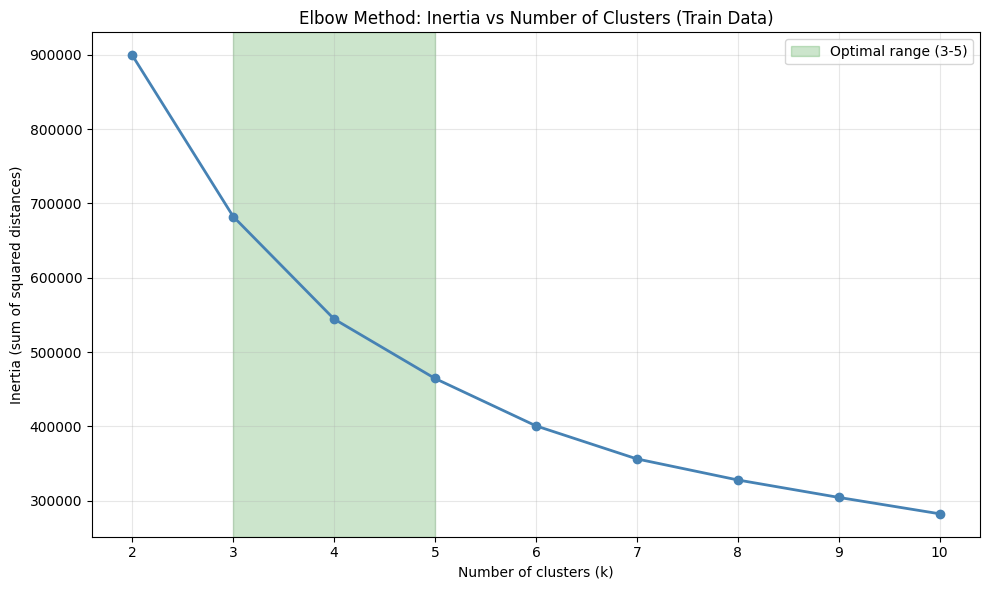

Elbow plot saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\features\clustering_elbow.png


In [27]:
# VISUALIZE ELBOW CURVE
fig, ax = plt.subplots(figsize = (10, 6))

ax.plot(inertia_df["k"], inertia_df["inertia"], marker = "o", linewidth = 2, color = "steelblue")
ax.set_title("Elbow Method: Inertia vs Number of Clusters (Train Data)")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia (sum of squared distances)")
ax.grid(alpha = 0.3)

# Mark the optimal range (3-5 clusters)
ax.axvspan(3, 5, alpha = 0.2, color = "green", label = "Optimal range (3-5)")
ax.legend()

plt.tight_layout()
fig.savefig(REPORTS_FEATURES_DIR / "clustering_elbow.png", dpi = 150)
plt.show()

print(f"Elbow plot saved to: {REPORTS_FEATURES_DIR / 'clustering_elbow.png'}")

In [28]:
# CHOOSE OPTIMAL K AND FIT FINAL KMEANS
OPTIMAL_K = 4  # Adjust based on elbow curve

print(f"Chosen optimal k: {OPTIMAL_K}")

kmeans_final = KMeans(
    n_clusters = OPTIMAL_K,
    random_state = RANDOM_STATE,
    n_init = 10
)

# Fit on train only
kmeans_final.fit(X_cluster_train_scaled)

# Predict on train and val
cluster_labels_train = kmeans_final.predict(X_cluster_train_scaled)
cluster_labels_val = kmeans_final.predict(X_cluster_val_scaled)

# Combine back in original order
cluster_labels_all = np.zeros(len(X_cluster_all), dtype = int)
cluster_labels_all[train_idx_cluster] = cluster_labels_train
cluster_labels_all[val_idx_cluster] = cluster_labels_val

print(f"\nCluster distribution (all data):")
unique, counts = np.unique(cluster_labels_all, return_counts = True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} users ({c / len(cluster_labels_all) * 100:.2f}%)")

print(f"\nCluster distribution (train only):")
unique_train, counts_train = np.unique(cluster_labels_train, return_counts = True)
for u, c in zip(unique_train, counts_train):
    print(f"  Cluster {u}: {c} users ({c / len(cluster_labels_train) * 100:.2f}%)")

Chosen optimal k: 4

Cluster distribution (all data):
  Cluster 0: 138160 users (55.26%)
  Cluster 1: 33942 users (13.58%)
  Cluster 2: 72576 users (29.03%)
  Cluster 3: 5322 users (2.13%)

Cluster distribution (train only):
  Cluster 0: 110543 users (55.27%)
  Cluster 1: 27080 users (13.54%)
  Cluster 2: 58145 users (29.07%)
  Cluster 3: 4232 users (2.12%)


In [30]:
# ADD CLUSTER AS FEATURE
all_features = all_features.with_columns(
    pl.Series("cluster", cluster_labels_all).cast(pl.Int32)
)

print(f"Final dataset shape after adding cluster: {all_features.shape}")
print(f"Number of features (excluding user_id, target, is_train): {len(all_features.columns) - 3}")

Final dataset shape after adding cluster: (250000, 64)
Number of features (excluding user_id, target, is_train): 61


In [31]:
# ANALYZE CLUSTERS (TRAIN DATA ONLY TO AVOID LEAKAGE)
# Filter to train data only
all_features_train = all_features.filter(
    pl.col("is_train") == 1
)

cluster_analysis = (
    all_features_train.group_by("cluster")
    .agg([
        pl.len().alias("n_users"),
        pl.col("orders_90d").mean().alias("avg_orders_90d"),
        pl.col("recency_order").mean().alias("avg_recency_order"),
        pl.col("total_gmv").mean().alias("avg_total_gmv"),
        pl.col("orders_per_active_day").mean().alias("avg_orders_per_active_day"),
        pl.col("active_days_30d").mean().alias("avg_active_days_30d"),
        pl.col("gmv_90d").mean().alias("avg_gmv_90d"),
        pl.col("target").mean().alias("avg_target"),
        pl.col("target").sum().alias("total_target"),
    ])
    .sort("avg_total_gmv", descending = True)
)

print("\nCluster analysis (train data):")
print(cluster_analysis)

# Convert to pandas for easier viewing
cluster_analysis_pd = cluster_analysis.to_pandas()
cluster_analysis_pd["pct_users"] = cluster_analysis_pd["n_users"] / cluster_analysis_pd["n_users"].sum() * 100
cluster_analysis_pd["pct_target"] = cluster_analysis_pd["total_target"] / cluster_analysis_pd["total_target"].sum() * 100

print("\nCluster distribution with percentages:")
print(cluster_analysis_pd[["cluster", "n_users", "pct_users", "avg_total_gmv", "avg_target", "pct_target"]].to_string(index = False))


Cluster analysis (train data):
shape: (4, 10)
┌─────────┬─────────┬────────────┬────────────┬───┬────────────┬───────────┬───────────┬───────────┐
│ cluster ┆ n_users ┆ avg_orders ┆ avg_recenc ┆ … ┆ avg_active ┆ avg_gmv_9 ┆ avg_targe ┆ total_tar │
│ ---     ┆ ---     ┆ _90d       ┆ y_order    ┆   ┆ _days_30d  ┆ 0d        ┆ t         ┆ get       │
│ i32     ┆ u32     ┆ ---        ┆ ---        ┆   ┆ ---        ┆ ---       ┆ ---       ┆ ---       │
│         ┆         ┆ f64        ┆ f64        ┆   ┆ f64        ┆ f64       ┆ f64       ┆ f64       │
╞═════════╪═════════╪════════════╪════════════╪═══╪════════════╪═══════════╪═══════════╪═══════════╡
│ 3       ┆ 4232    ┆ 83.636106  ┆ 4.050803   ┆ … ┆ 21.486531  ┆ 3351.6079 ┆ 749.61462 ┆ 3.1724e6  │
│         ┆         ┆            ┆            ┆   ┆            ┆ 82        ┆ 7         ┆           │
│ 2       ┆ 58145   ┆ 18.029598  ┆ 11.717792  ┆ … ┆ 19.970694  ┆ 567.30047 ┆ 153.51237 ┆ 8.9260e6  │
│         ┆         ┆            ┆          

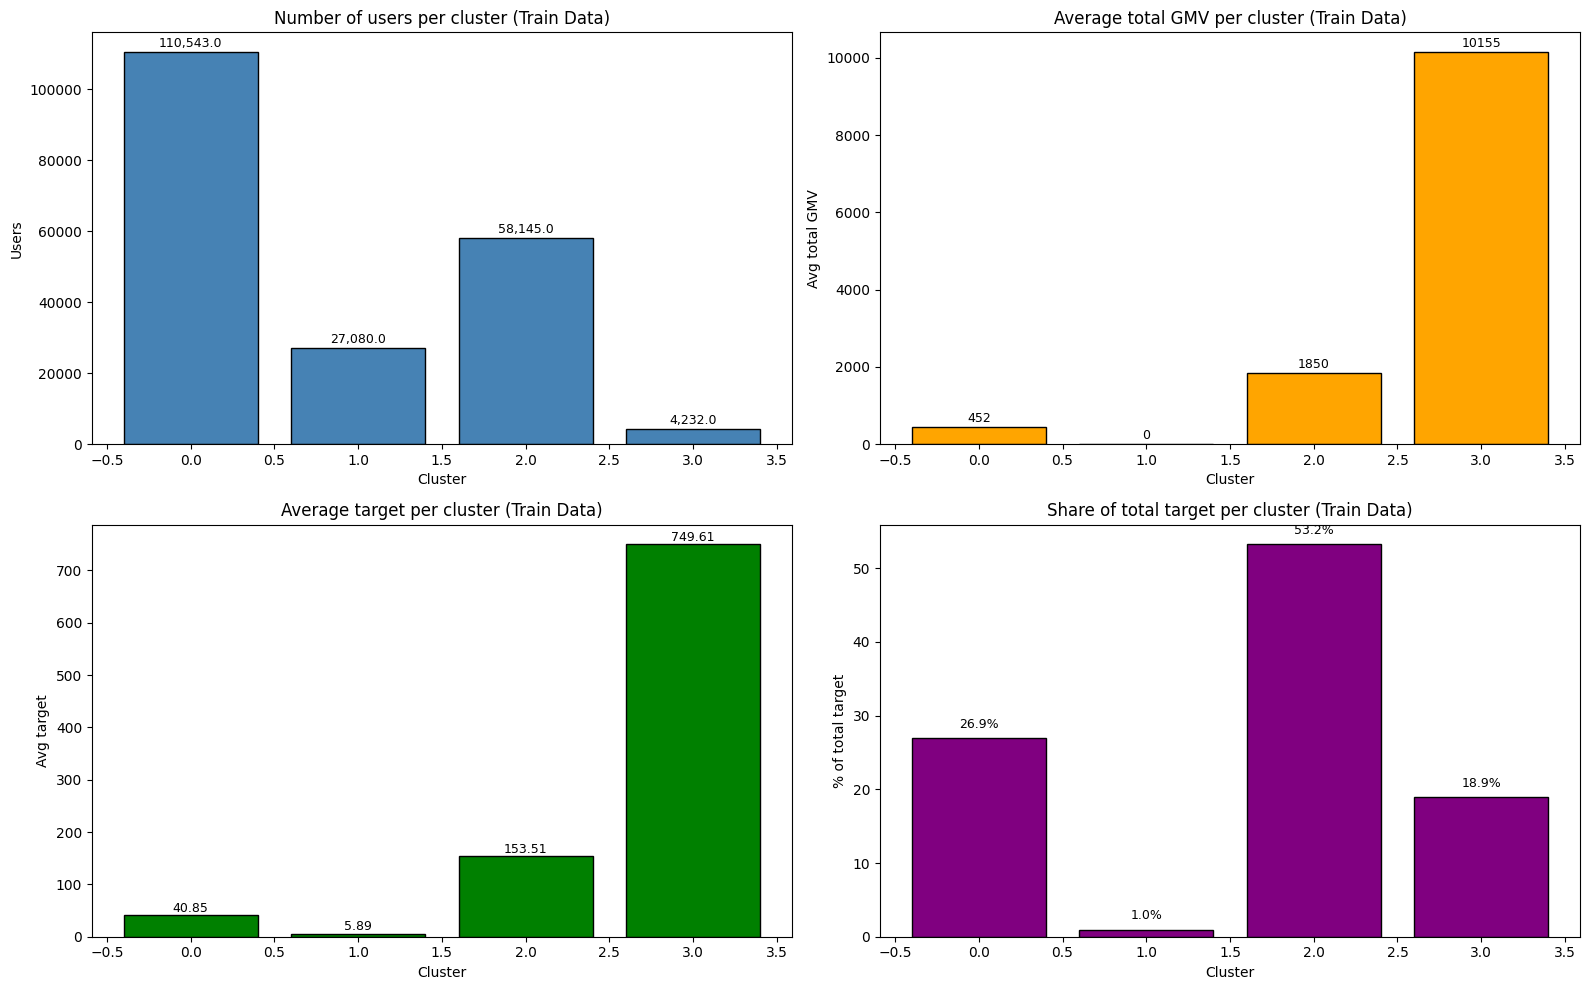

Cluster analysis plot saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\features\clustering_analysis.png


In [33]:
# VISUALIZE CLUSTERS
cluster_analysis_pd = cluster_analysis_pd.sort_values("cluster").reset_index(drop = True)

fig, axes = plt.subplots(2, 2, figsize = (16, 10))

# Plot 1: Number of users per cluster
axes[0, 0].bar(cluster_analysis_pd["cluster"], cluster_analysis_pd["n_users"], 
               color = "steelblue", edgecolor = "black")
axes[0, 0].set_title("Number of users per cluster (Train Data)")
axes[0, 0].set_xlabel("Cluster")
axes[0, 0].set_ylabel("Users")
for i, row in cluster_analysis_pd.iterrows():
    axes[0, 0].text(i, row["n_users"] + 500, f"{row['n_users']:,}", 
                    ha = "center", va = "bottom", fontsize = 9)

# Plot 2: Average total GMV per cluster
axes[0, 1].bar(cluster_analysis_pd["cluster"], cluster_analysis_pd["avg_total_gmv"], 
               color = "orange", edgecolor = "black")
axes[0, 1].set_title("Average total GMV per cluster (Train Data)")
axes[0, 1].set_xlabel("Cluster")
axes[0, 1].set_ylabel("Avg total GMV")
for i, row in cluster_analysis_pd.iterrows():
    axes[0, 1].text(i, row["avg_total_gmv"] + 50, f"{row['avg_total_gmv']:.0f}", 
                    ha = "center", va = "bottom", fontsize = 9)

# Plot 3: Average target per cluster
axes[1, 0].bar(cluster_analysis_pd["cluster"], cluster_analysis_pd["avg_target"], 
               color = "green", edgecolor = "black")
axes[1, 0].set_title("Average target per cluster (Train Data)")
axes[1, 0].set_xlabel("Cluster")
axes[1, 0].set_ylabel("Avg target")
for i, row in cluster_analysis_pd.iterrows():
    axes[1, 0].text(i, row["avg_target"] + 1, f"{row['avg_target']:.2f}", 
                    ha = "center", va = "bottom", fontsize = 9)

# Plot 4: Share of total target per cluster
axes[1, 1].bar(cluster_analysis_pd["cluster"], cluster_analysis_pd["pct_target"], 
               color = "purple", edgecolor = "black")
axes[1, 1].set_title("Share of total target per cluster (Train Data)")
axes[1, 1].set_xlabel("Cluster")
axes[1, 1].set_ylabel("% of total target")
for i, row in cluster_analysis_pd.iterrows():
    axes[1, 1].text(i, row["pct_target"] + 1, f"{row['pct_target']:.1f}%", 
                    ha = "center", va = "bottom", fontsize = 9)

plt.tight_layout()
fig.savefig(REPORTS_FEATURES_DIR / "clustering_analysis.png", dpi = 150)
plt.show()

print(f"Cluster analysis plot saved to: {REPORTS_FEATURES_DIR / 'clustering_analysis.png'}")

In [34]:
# SAVE COMBINED FEATURES
all_features.write_parquet(CV_FEATURES_PATH)

print(f"Features saved to: {CV_FEATURES_PATH}")
print(f"File size: {CV_FEATURES_PATH.stat().st_size / 1024 / 1024:.2f} MB")

Features saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\data\processed\features\cv_features_2026-01-14.parquet
File size: 32.12 MB
